# RSNA Pediatric Bone Age Estimation

This notebook implements a deep-learning pipeline to predict bone age from hand radiographs using the RSNA Bone Age dataset. First, I mounted Google Drive and installed the required dependencies (including `kagglehub`), then loaded the training and testing CSV files and mapped each record to its corresponding image path.

After loading the data, data analysis was performed. I computed summary statistics for the bone age values—observing a range from newborns up to 228 months with a slight right skew—and visualized this distribution using histograms and kernel density plots.

Next, I examined the patient sex distribution, finding an approximately balanced male/female split, and generated separate age-by-sex boxplots to highlight any subgroup differences or outliers. I also checked for missing values ,and applied label encoding to convert the `Sex` column into a binary feature, and normalized bone age into a consistent scale for regression.

In [1]:
# Colab Drive mount removed for local execution.

In [2]:
# drive.mount removed for local execution.

In [3]:
# # These lines of code are only needed when uploading a file
# from google.colab import files
# files.upload()

In [4]:
import os
from pathlib import Path

# Single source of truth for the local RSNA training data. Override by exporting
# BONE_AGE_DATA_ROOT before launching Jupyter.
DATA_ROOT = Path(
    os.environ.get(
        "BONE_AGE_DATA_ROOT",
        "/home/spacing/Emir/Boneage UQ/data/rsna_training",
    )
).resolve()

# Both shipped variants of the official RSNA layout are tolerated.
_candidate_image_dirs = [
    DATA_ROOT / "boneage-training-dataset" / "boneage-training-dataset",
    DATA_ROOT / "boneage-training-dataset",
]
IMAGES_DIR = next((p for p in _candidate_image_dirs if p.is_dir()), _candidate_image_dirs[0])

_candidate_csvs = [
    DATA_ROOT / "boneage-training-dataset.csv",
    DATA_ROOT / "train.csv",
]
TRAIN_CSV = next((p for p in _candidate_csvs if p.is_file()), _candidate_csvs[0])

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"TRAIN_CSV = {TRAIN_CSV}")
print(f"IMAGES_DIR = {IMAGES_DIR}")


DATA_ROOT = /home/spacing/Emir/Boneage UQ/data/rsna_training
TRAIN_CSV = /home/spacing/Emir/Boneage UQ/data/rsna_training/train.csv
IMAGES_DIR = /home/spacing/Emir/Boneage UQ/data/rsna_training/boneage-training-dataset


In [5]:

#Import all the required functions and library
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Concatenate



from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

I0000 00:00:1777514767.659204 2660535 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777514767.713894 2660535 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777514769.015094 2660535 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Dataset
I loaded a total of 12,611 labeled hand radiographs for training (and its held-out 3,000-image validation split) plus 200 unlabeled test images, and fed them into TensorFlow’s `tf.data` pipeline at a batch size of 32—yielding 316 training batches, 79 validation batches, and 7 test batches.
 I then examined the overall bone-age distribution, plotting both month-based and year-based histograms (with KDE overlays).
 I computed summary statistics (count, mean, std, min, quartiles, and max) on both the raw `boneage` and its normalized “age\_years” equivalent, applied label encoding to transform `Sex` into a binary feature and also performed data augmentation.

In [6]:
# Output directory for saved models (local; override with BONE_AGE_OUTPUT_DIR).
OUTPUT_DIR = Path(
    os.environ.get(
        "BONE_AGE_OUTPUT_DIR",
        "/home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models",
    )
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Single-GPU setup: use GPU:0 when available, otherwise CPU.
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], "GPU")
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"Using single GPU device: {gpus[0].name}")
    except RuntimeError as e:
        print(f"GPU configuration warning: {e}")
else:
    print("No GPU detected. Running on CPU.")


Using single GPU device: /physical_device:GPU:0


In [7]:
# Local image directory. test_dir mirrors train_dir because we are using only
# the official RSNA training set and producing our own train/val/test splits below.
train_dir = IMAGES_DIR
test_dir  = IMAGES_DIR


In [8]:
# Load the official RSNA training annotations from the local copy.
full_df = pd.read_csv(TRAIN_CSV)

# Normalize column names. The official zip uses ('id', 'boneage', 'male'); some
# Kaggle mirrors rename to ('fileName', 'boneage', 'male'). Map both to 'id'.
if "id" not in full_df.columns and "fileName" in full_df.columns:
    full_df["id"] = full_df["fileName"].astype(str).str.replace(".png", "", regex=False)

full_df["filepath"] = full_df["id"].astype(str).apply(lambda x: str(train_dir / f"{x}.png"))

# 80 / 10 / 10 split (train / val / test) stratified on sex.
train_df, _temp_df = train_test_split(
    full_df,
    test_size=0.20,
    random_state=42,
    stratify=full_df["male"],
)
val_df, test_df = train_test_split(
    _temp_df,
    test_size=0.50,
    random_state=42,
    stratify=_temp_df["male"],
)

# Reset indices so downstream .iloc / sample lookups behave predictably.
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Normalize the regression target (months -> [0, 1]) using the train max.
max_age = train_df["boneage"].max()
for _df in (train_df, val_df, test_df):
    _df["boneage_norm"] = _df["boneage"] / max_age

print(f"Sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")


Sizes -> train: 10088, val: 1261, test: 1262


In [9]:
# Show the first 5 rows of the training DataFrame
print("training data")
display(train_df.head())

# Show the first 5 rows of the testing DataFrame
print("testing data")
display(test_df.head())


training data


,id,boneage,male,filepath,boneage_norm
0,10013,120,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.526316
1,2062,84,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.368421
2,14995,150,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.657895
3,14023,108,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.473684
4,11862,174,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.763158


testing data


,id,boneage,male,filepath,boneage_norm
0,14014,120,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.526316
1,7295,96,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.421053
2,11734,108,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.473684
3,2776,180,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.789474
4,4573,72,False,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.315789


In [10]:
# Display 5 random rows from the train DataFrame
print("Random Training dataset")
display(train_df.sample(5,random_state=42))

# Display 5 random rows from the test DataFrame
print("Random Testing dataset")
display(test_df.sample(5,random_state=42))


Random Training dataset


,id,boneage,male,filepath,boneage_norm
9939,12587,162,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.710526
568,5668,132,False,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.578947
8264,11287,156,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.684211
2344,5870,106,False,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.464912
5708,2053,132,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.578947


Random Testing dataset


,id,boneage,male,filepath,boneage_norm
1206,10351,94,False,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.412281
868,4157,150,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.657895
532,10342,126,False,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.552632
344,9019,174,True,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.763158
405,4083,180,False,/home/spacing/Emir/Boneage UQ/data/rsna_traini...,0.789474


In [11]:
# Structural summary of training dataset
print("training data info")
display(train_df.info())

# structural summary of the testing dataset
print("testing data info")
display(test_df.info() )

training data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10088 entries, 0 to 10087
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10088 non-null  int64  
 1   boneage       10088 non-null  int64  
 2   male          10088 non-null  bool   
 3   filepath      10088 non-null  object 
 4   boneage_norm  10088 non-null  float64
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 325.2+ KB


None

testing data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1262 non-null   int64  
 1   boneage       1262 non-null   int64  
 2   male          1262 non-null   bool   
 3   filepath      1262 non-null   object 
 4   boneage_norm  1262 non-null   float64
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 40.8+ KB


None

In [12]:
# summary statistics for all numeric columns
print("Age distribution")
train_df['age_years']=(train_df['boneage']/12).round(8)
display(train_df.describe())

Age distribution


,id,boneage,boneage_norm,age_years
count,10088.000000,10088.000000,10088.000000,10088.000000
mean,8504.406324,127.297780,0.558324,10.608148
std,4102.447829,41.051244,0.180049,3.420937
min,1377.000000,1.000000,0.004386,0.083333
25%,5044.500000,96.000000,0.421053,8.000000
50%,8530.500000,132.000000,0.578947,11.000000
75%,12047.250000,156.000000,0.684211,13.000000
max,15608.000000,228.000000,1.000000,19.000000


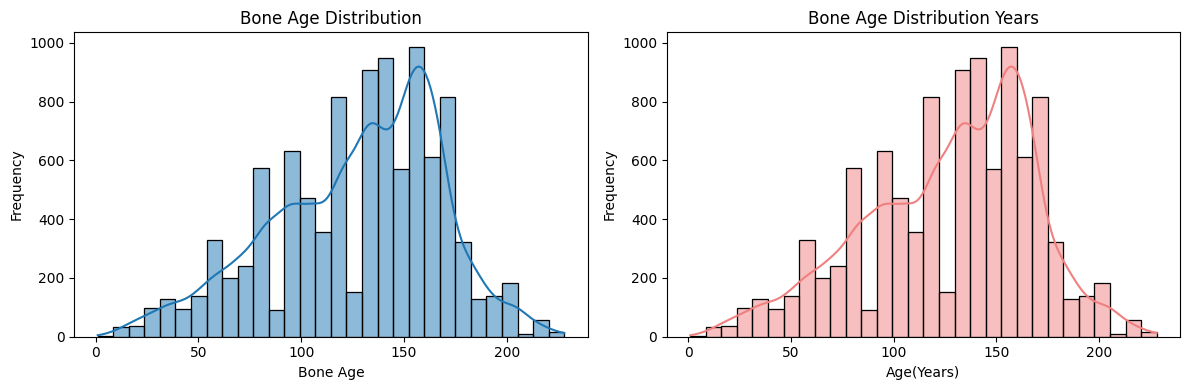

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Bone age distribution in months
sns.histplot(train_df['boneage'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Bone Age Distribution')
axes[0].set_xlabel('Bone Age')
axes[0].set_ylabel('Frequency')

#Bone age distribution in years
sns.histplot(train_df['boneage'], bins=30, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Bone Age Distribution Years')
axes[1].set_xlabel('Age(Years)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2660535/2477645703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='male', data=train_df, palette=['lightpink', 'lightblue'])


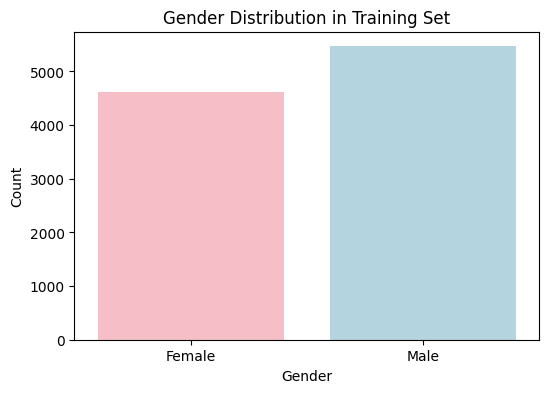

In [14]:
# Gender Distribution in Training Set
plt.figure(figsize=(6, 4))
sns.countplot(x='male', data=train_df, palette=['lightpink', 'lightblue'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution in Training Set')
plt.xticks(ticks=[0, 1], labels=["Female", "Male"])
plt.show()

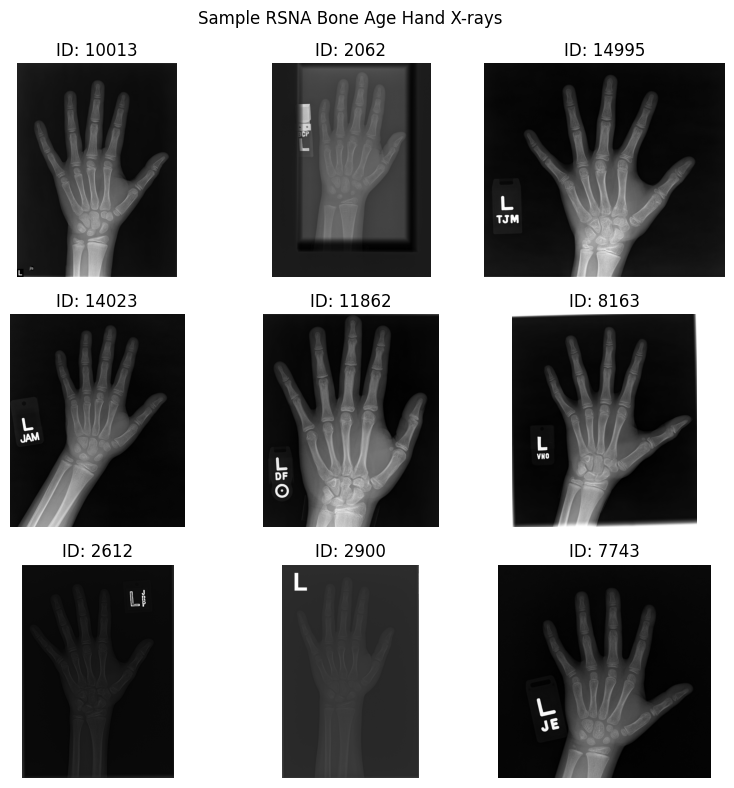

In [15]:
# Display the first 9 images in a 3×3 grid
plt.figure(figsize=(8,8))
for i, img_path in enumerate(train_df['filepath'][:9]):
    plt.subplot(3,3,i+1)
    img = Image.open(img_path)
    plt.imshow(img, cmap='gray')
    plt.title(f"ID: {train_df.iloc[i]['id']}")
    plt.axis('off')
plt.suptitle("Sample RSNA Bone Age Hand X-rays")
plt.tight_layout()
plt.show()

In [16]:
img_size   = (300, 300)
# Single-GPU batch size.
batch_size = 32

In [17]:
# define the parser
def parse_single(filepath, age):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = effnet_preprocess(img)
    age = tf.cast(age, tf.float32)
    return img, tf.expand_dims(age, -1)

# Now build ds_train
ds_train = tf.data.Dataset.from_tensor_slices((
    train_df['filepath'].values,
    train_df['boneage_norm'].values
))
ds_train = (
    ds_train
    .map(parse_single, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(1024, seed=42)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# build ds_val
ds_val = tf.data.Dataset.from_tensor_slices((
    val_df['filepath'].values,
    val_df['boneage_norm'].values
))
ds_val = (
    ds_val
    .map(parse_single, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# build ds_test
ds_test = tf.data.Dataset.from_tensor_slices(test_df['filepath'].values)
ds_test = (
    ds_test
    .map(lambda fp: tf.image.resize(
             effnet_preprocess(
               tf.image.decode_png(tf.io.read_file(fp), channels=3)
             ),
             img_size
           ),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"DS train batches: {ds_train.cardinality().numpy()} batches of {batch_size}")
print(f"DS val   batches: {ds_val.cardinality().numpy()} batches of {batch_size}")
print(f"DS test  batches: {ds_test.cardinality().numpy()} batches of {batch_size}")



I0000 00:00:1777514773.377779 2660535 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14263 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:19:00.0, compute capability: 8.6


DS train batches: 316 batches of 32
DS val   batches: 40 batches of 32
DS test  batches: 40 batches of 32


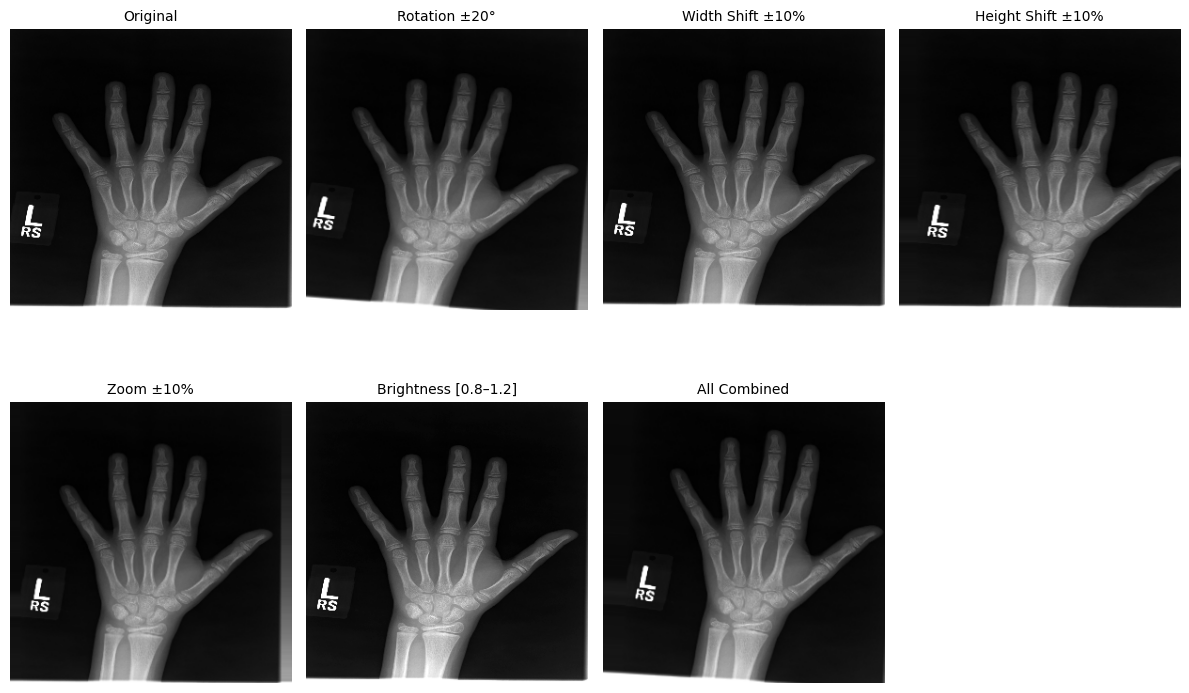

In [18]:
# Load one image from the validation set
img_path   = val_df['filepath'].iloc[0]
img        = load_img(img_path, target_size=img_size)
img_array  = img_to_array(img)                  # shape=(224,224,3), values [0–255]
img_array  = np.expand_dims(img_array, axis=0)  # shape=(1,224,224,3)

# Define augmentations
augmentations = {
    "Original":         ImageDataGenerator(preprocessing_function=effnet_preprocess),
    "Rotation ±20°":    ImageDataGenerator(preprocessing_function=effnet_preprocess,
                                           rotation_range=20),
    "Width Shift ±10%": ImageDataGenerator(preprocessing_function=effnet_preprocess,
                                           width_shift_range=0.1),
    "Height Shift ±10%":ImageDataGenerator(preprocessing_function=effnet_preprocess,
                                           height_shift_range=0.1),
    "Zoom ±10%":        ImageDataGenerator(preprocessing_function=effnet_preprocess,
                                           zoom_range=0.1),
    "Brightness [0.8–1.2]": ImageDataGenerator(preprocessing_function=effnet_preprocess,
                                               brightness_range=[0.8,1.2]),
    "All Combined":     ImageDataGenerator(preprocessing_function=effnet_preprocess,
                                           rotation_range=20,
                                           width_shift_range=0.1,
                                           height_shift_range=0.1,
                                           zoom_range=0.1,
                                           brightness_range=[0.8,1.2],
                                           fill_mode='nearest'),
}

# Plot each augmented version
plt.figure(figsize=(12, 8))
for i, (name, gen) in enumerate(augmentations.items()):
    aug_iter = gen.flow(img_array, batch_size=1)
    aug_img  = next(aug_iter)[0].astype(np.uint8)

    plt.subplot(2, 4, i+1)
    plt.imshow(aug_img)
    plt.title(name, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()




### Models
Both of the architectures build are on an ImageNet-pretrained EfficientNet-B3 backbone, but differ in how they fuse auxiliary information for bone-age regression. The **baseline model **simply strips off EfficientNet’s classifier head, applies global average pooling to the final feature maps, and then passes them through a 256-unit ReLU + dropout block before a single linear neuron that predicts normalized bone age.

 In contrast, the **multi-input model** takes those same visual features, concatenates them with a one-dimensional sex indicator (0 or 1), and then routes the combined vector through the same 256-unit ReLU + dropout block into its final regression output—allowing the network to learn gender-specific growth patterns alongside purely radiographic cues.

To see how each prediction are made , I generate **Grad-CAM heatmaps** by computing the gradient of the bone-age output with respect to the last convolutional feature maps.
After globally averaging these gradients, I weight and sum the feature maps to produce a coarse localization map, then overlay it in transparent red over the original X-ray.
These heatmaps consistently highlight the growth plates and carpals—regions that human readers also focus on—providing confidence that the model is attending to medically relevant anatomy rather than spurious artifacts.


In [19]:
# baseline model (built and compiled inside the multi-GPU strategy scope)
def build_baseline_model(input_shape=(300,300,3), dropout=0.5):
    base = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape

    )
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout)(x)
    out = Dense(1, activation='linear')(x)   # predicts normalized boneage

    model = Model(inputs=base.input, outputs=out, name="EffNetB3_baseline")
    model.compile(
        optimizer=Adam(1e-4),
        loss='mean_absolute_error',
        metrics=['mean_absolute_error', 'mean_squared_error']
    )
    return model

model = build_baseline_model()
model.summary()


Model: "EffNetB3_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,177,264 (42.64 MB)

 Trainable params: 11,089,961 (42.30 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [20]:
# Callbacks: best-checkpoint, early stop, and per-epoch CSV log (train/val MAE).
checkpoint = ModelCheckpoint(
    filepath=str(OUTPUT_DIR / "best_baseline_{epoch:02d}-{val_mean_absolute_error:.3f}.keras"),
    monitor="val_mean_absolute_error",
    save_best_only=True,
    verbose=1,
)
early_stop = EarlyStopping(
    monitor="val_mean_absolute_error",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)
csv_logger = CSVLogger(str(OUTPUT_DIR / "training_log_baseline.csv"), append=False)


In [21]:
# training
lr_scheduler = ReduceLROnPlateau(
    monitor='val_mean_absolute_error',
    factor=0.5,       # cut LR in half
    patience=5,       # wait 5 epochs without improvement
    min_lr=1e-6,      #o
    verbose=1
)

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    callbacks=[early_stop, checkpoint, lr_scheduler, csv_logger],
    verbose=2,
)

Epoch 1/50


I0000 00:00:1777514816.007591 2670171 service.cc:153] XLA service 0x7c06bc04c490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777514816.007614 2670171 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A4000, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777514817.582546 2670171 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777514824.027679 2670171 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777514825.881163 2670171 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_77061__.708
E0000 00:00:1777514829.716396 2670171 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777514835.271402 2670171 cuda_timer.cc:87] Delay kernel timed out: measured ti


Epoch 1: val_mean_absolute_error improved from None to 0.09517, saving model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/best_baseline_01-0.095.keras
316/316 - 328s - 1s/step - loss: 0.1790 - mean_absolute_error: 0.1790 - mean_squared_error: 0.0552 - val_loss: 0.0952 - val_mean_absolute_error: 0.0952 - val_mean_squared_error: 0.0144 - learning_rate: 1.0000e-04
Epoch 2/50

Epoch 2: val_mean_absolute_error improved from 0.09517 to 0.06872, saving model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/best_baseline_02-0.069.keras
316/316 - 75s - 237ms/step - loss: 0.1096 - mean_absolute_error: 0.1096 - mean_squared_error: 0.0193 - val_loss: 0.0687 - val_mean_absolute_error: 0.0687 - val_mean_squared_error: 0.0077 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 3: val_mean_absolute_error improved from 0.06872 to 0.06500, saving model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/bes

In [22]:
import pickle

baseline_final_path = OUTPUT_DIR / "baseline_final.keras"
model.save(baseline_final_path)
print("Saved final baseline model to", baseline_final_path)

with open(OUTPUT_DIR / "history_baseline.pkl", "wb") as f:
    pickle.dump(history.history, f)

# Also persist the full keras-history-style metric table as CSV for quick diffing.
pd.DataFrame(history.history).to_csv(OUTPUT_DIR / "history_baseline.csv", index_label="epoch")
print("Saved baseline training history.")

Saved final baseline model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/baseline_final.keras
Saved baseline training history.


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


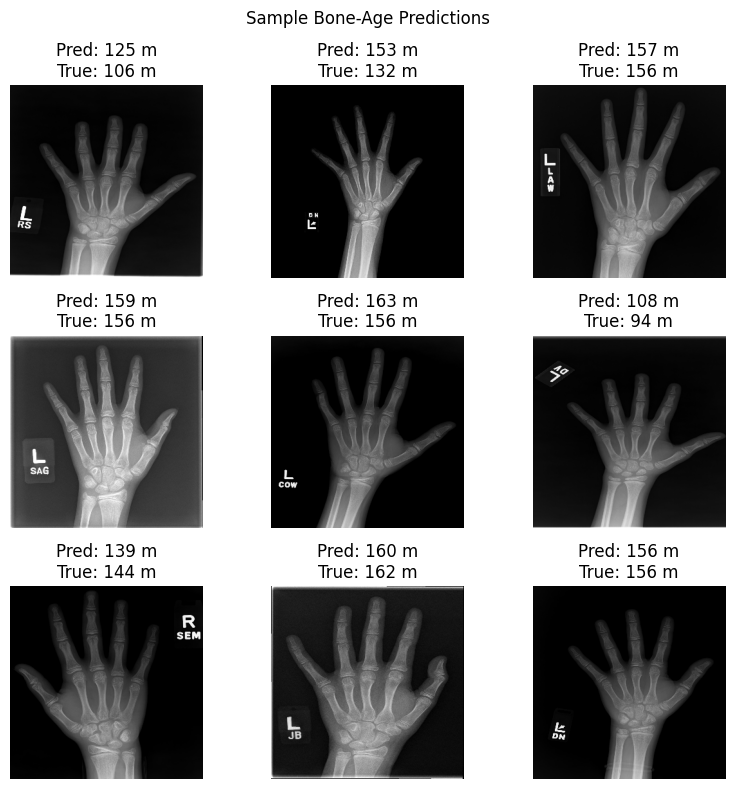

In [23]:
batch = next(iter(ds_val))
imgs, age_norm = batch

# Denormalize true ages and get predictions
max_age = train_df['boneage'].max()
y_true_month = age_norm.numpy().flatten() * max_age
y_pred_month = model.predict(imgs).flatten() * max_age

# Plot a 3×3 grid of sample predictions
import matplotlib.pyplot as plt

n = min(len(imgs), 9)
plt.figure(figsize=(8,8))
for i in range(n):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(imgs[i].numpy().astype('uint8'))
    plt.title(f"Pred: {y_pred_month[i]:.0f} m\nTrue: {y_true_month[i]:.0f} m")
    plt.axis('off')
plt.suptitle("Sample Bone-Age Predictions")
plt.tight_layout()
plt.show()



In [24]:
# Evaluate and dict of all metrics
results = model.evaluate(ds_val, verbose=1, return_dict=True)

val_mae = results['mean_absolute_error']     # normalized units
val_mse = results['mean_squared_error']      # normalized units

print(f"Validation MAE: {val_mae*100:.1f} months")
print(f"Validation MSE: {val_mse*10000:.3f} (months²)")


 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0310 - mean_absolute_error: 0.0310 - mean_squared_error: 0.0019

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0412 - mean_absolute_error: 0.0412 - mean_squared_error: 0.0030
Validation MAE: 4.1 months
Validation MSE: 29.607 (months²)


In [25]:
# Run inference on the tf.data.Dataset,
y_test_norm = model.predict(ds_test, verbose=1).flatten()

# De-normalize back to actual months using the same max_age
y_test_pred = y_test_norm * max_age

# Attach predictions to your test_df
test_df['boneage_pred'] = y_test_pred

# Display the first 10 predictions
display(test_df[['id', 'boneage', 'boneage_pred']].head(10))


39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

E0000 00:00:1777518568.560868 2670173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518572.183824 2670173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 646ms/step


,id,boneage,boneage_pred
0,14014,120,125.124876
1,7295,96,94.276243
2,11734,108,95.970579
3,2776,180,180.960959
4,4573,72,93.725384
5,8039,186,173.249475
6,5806,138,155.937299
7,9097,162,157.789950
8,2935,168,172.464715
9,10680,156,151.956993


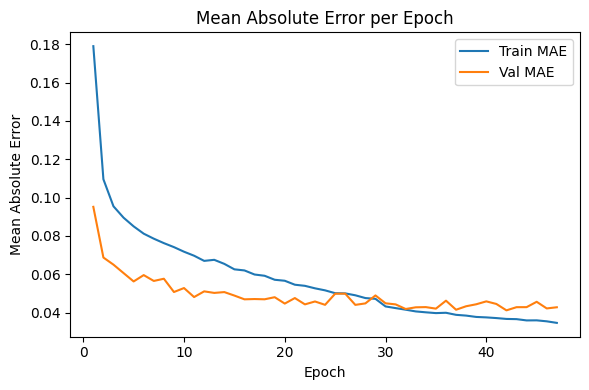

In [26]:
# MAE per epoch
epochs = range(1, len(history.history['mean_absolute_error']) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history.history['mean_absolute_error'],     label='Train MAE')
plt.plot(epochs, history.history['val_mean_absolute_error'], label='Val MAE')
plt.title('Mean Absolute Error per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.tight_layout()
plt.show()

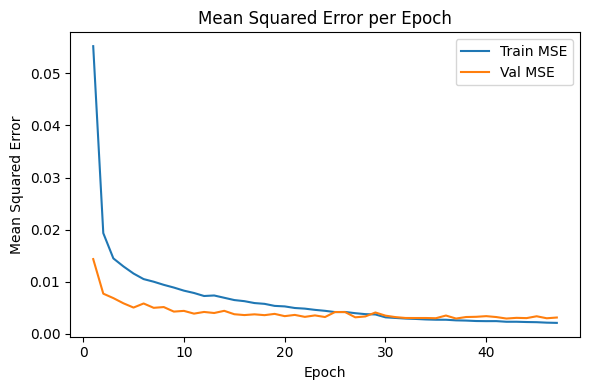

In [27]:
#MSE per epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs, history.history['mean_squared_error'],     label='Train MSE')
plt.plot(epochs, history.history['val_mean_squared_error'], label='Val MSE')
plt.title('Mean Squared Error per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# predictions on  validation set
y_norm_pred = model.predict(ds_val, verbose=1).flatten()

# Denormalize back to months
y_pred = y_norm_pred * 100.0

# True ages (in months)
y_true = val_df['boneage_norm'].values * 100.0

# Compute metrics
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)
acc6  = np.mean(np.abs(y_pred - y_true) <= 6.0) * 100  # % within ±6 months
acc12 = np.mean(np.abs(y_pred - y_true) <= 12.0) * 100 # % within ±12 months

# Print summary
print(f"MAE:   {mae:.2f} months")
print(f"RMSE:  {rmse:.2f} months")
print(f"MSE:   {mse:.2f}")
print(f"R²:    {r2:.3f}")
print(f"% within ±6 mo:  {acc6:.1f}%")
print(f"% within ±12 mo: {acc12:.1f}%")


40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 266ms/step
MAE:   4.12 months
RMSE:  5.44 months
MSE:   29.61
R²:    0.912
% within ±6 mo:  75.9%
% within ±12 mo: 96.4%


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


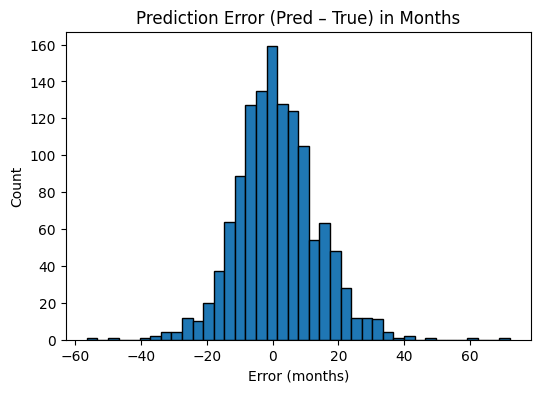

In [29]:
# Get predictions (normalized)
y_pred_norm = model.predict(ds_val).flatten()

# Extract the true normalized ages
y_true_norm = np.concatenate([
    y.numpy().flatten()
    for _, y in ds_val
], axis=0)

#  De‐normalize back to months (use the same max_age you used above)
y_pred_months = y_pred_norm * max_age
y_true_months = y_true_norm * max_age

# Compute errors in months
errors = y_pred_months - y_true_months

# Plot their histogram
plt.figure(figsize=(6,4))
plt.hist(errors, bins=40, edgecolor='black')
plt.title('Prediction Error (Pred – True) in Months')
plt.xlabel('Error (months)')
plt.ylabel('Count')
plt.show()

In [30]:
# Parse function for multi-input
def parse_multi(filepath, sex, age):
    # Load & preprocess image
    img = tf.io.read_file(filepath)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = effnet_preprocess(img)

    # Cast numeric inputs
    sex = tf.cast(sex, tf.float32)
    age = tf.cast(age, tf.float32)

    return (
        {'image_input': img, 'sex_input': tf.expand_dims(sex, -1)},
        tf.expand_dims(age, -1)
    )

In [31]:
for df in (train_df, val_df):
    df['sex_norm'] = df['male'].astype('float32')
# Build tf.data datasets
ds_train = tf.data.Dataset.from_tensor_slices((
    train_df['filepath'].values,
    train_df['sex_norm'].values,
    train_df['boneage_norm'].values
))
ds_train = (
    ds_train
      .map(parse_multi, num_parallel_calls=tf.data.AUTOTUNE)
      .cache()
      .shuffle(1024, seed=42)
      .batch(batch_size)
      .prefetch(tf.data.AUTOTUNE)
)

ds_val = tf.data.Dataset.from_tensor_slices((
    val_df['filepath'].values,
    val_df['sex_norm'].values,
    val_df['boneage_norm'].values
))
ds_val = (
    ds_val
      .map(parse_multi, num_parallel_calls=tf.data.AUTOTUNE)
      .cache()
      .batch(batch_size)
      .prefetch(tf.data.AUTOTUNE)
)


In [32]:
# Build & compile the multi-input model (single-GPU / single-device)
def build_multi_input_model(dropout=0.5):
    img_input = Input(shape=(*img_size,3), name='image_input')
    sex_input = Input(shape=(1,),      name='sex_input')

    x = EfficientNetB3(weights='imagenet', include_top=False)(img_input)
    feat = GlobalAveragePooling2D()(x)

    x = Concatenate()([feat, sex_input])
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout)(x)
    out = Dense(1, activation='linear', name='boneage_output')(x)

    m = Model([img_input, sex_input], out, name='multi_input')
    m.compile(
        optimizer=Adam(1e-4),
        loss='mean_absolute_error',
        metrics=['mean_absolute_error']
    )
    return m

model = build_multi_input_model()
model.summary()

Model: "multi_input"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 9, 9,      │ 10,783,535 │ image_input[0][0] │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sex_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1537)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ sex_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    393,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ boneage_output      │ (None, 1)         │        257 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,177,520 (42.64 MB)

 Trainable params: 11,090,217 (42.31 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [33]:
# Callbacks: best-checkpoint, early stop, and per-epoch CSV log (train/val MAE).
checkpoint = ModelCheckpoint(
    str(OUTPUT_DIR / "best_multi_input_{epoch:02d}-{val_mean_absolute_error:.3f}.keras"),
    monitor="val_mean_absolute_error",
    save_best_only=True,
    verbose=1,
)
early_stop = EarlyStopping(
    monitor="val_mean_absolute_error",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)
csv_logger = CSVLogger(str(OUTPUT_DIR / "training_log_multi_input.csv"), append=False)



In [34]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_mean_absolute_error',
    factor=0.5,        # cut LR in half when plateauing
    patience=5,        # wait 5 epochs without improvement
    min_lr=1e-6,       # never go below this LR
    verbose=1
)
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=40,
    callbacks=[early_stop, checkpoint, lr_scheduler, csv_logger],
    verbose=2,
)


Epoch 1/40


I0000 00:00:1777518654.461077 2670173 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_321859__.706
E0000 00:00:1777518659.381186 2670173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518660.166023 2670173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518660.625773 2670173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518667.410892 2670173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777518668.529855 2670173 cuda_timer.cc:87] Delay kernel timed o


Epoch 1: val_mean_absolute_error improved from None to 0.09087, saving model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/best_multi_input_01-0.091.keras
316/316 - 262s - 829ms/step - loss: 0.1823 - mean_absolute_error: 0.1823 - val_loss: 0.0909 - val_mean_absolute_error: 0.0909 - learning_rate: 1.0000e-04
Epoch 2/40

Epoch 2: val_mean_absolute_error improved from 0.09087 to 0.06196, saving model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/best_multi_input_02-0.062.keras
316/316 - 72s - 227ms/step - loss: 0.1031 - mean_absolute_error: 0.1031 - val_loss: 0.0620 - val_mean_absolute_error: 0.0620 - learning_rate: 1.0000e-04
Epoch 3/40

Epoch 3: val_mean_absolute_error improved from 0.06196 to 0.05542, saving model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/best_multi_input_03-0.055.keras
316/316 - 72s - 229ms/step - loss: 0.0908 - mean_absolute_error: 0.0908 - val_loss: 0.

In [35]:
# Save final model + history (CSV + pickle) for later inference / plotting.
import pickle

multi_input_final_path = OUTPUT_DIR / "multi_input_final.keras"
model.save(multi_input_final_path)
print("Saved final multi-input model to", multi_input_final_path)

with open(OUTPUT_DIR / "history_multi.pkl", "wb") as f:
    pickle.dump(history.history, f)
pd.DataFrame(history.history).to_csv(OUTPUT_DIR / "history_multi.csv", index_label="epoch")

print("Training complete - history saved to", OUTPUT_DIR / "history_multi.csv")

Saved final multi-input model to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/multi_input_final.keras
Training complete - history saved to /home/spacing/Emir/Boneage UQ/tf-pediatric-bone-age/outputs/rsna_boneage_models/history_multi.csv


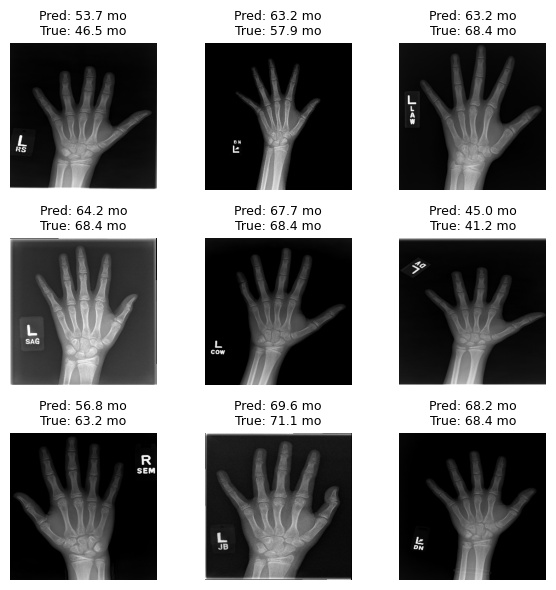

In [36]:
# Grab one batch from ds_val
(inputs, ages_true_norm) = next(iter(ds_val))
imgs = inputs['image_input']   # shape=(batch,224,224,3)
sexs = inputs['sex_input']     # shape=(batch,1)

# Predict on multi-input
y_norm_pred   = model.predict((imgs, sexs), verbose=0).flatten()
y_pred_months = y_norm_pred * 100.0
y_true_months = ages_true_norm.numpy().squeeze() * 100.0

# Plot up to 9 samples
n = min(imgs.shape[0], 9)
plt.figure(figsize=(6,6))
for i in range(n):
    ax = plt.subplot(3, 3, i+1)
    ax.imshow(imgs[i].numpy().astype('uint8'))  # or a simple clip if preprocessed
    ax.set_title(f"Pred: {y_pred_months[i]:.1f} mo\nTrue: {y_true_months[i]:.1f} mo",
                 fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()



40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 270ms/step


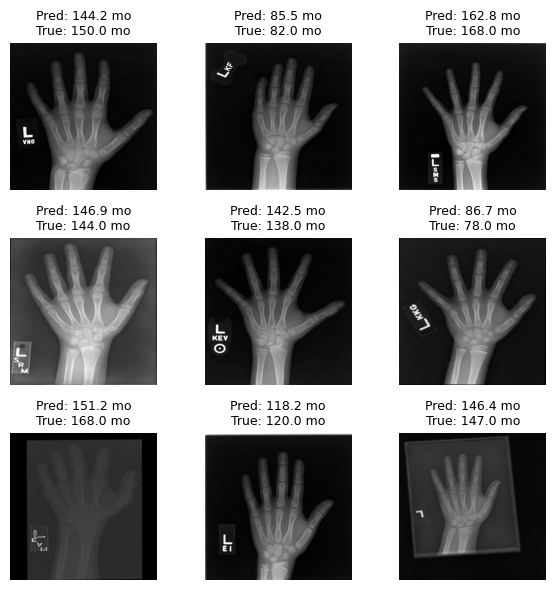

In [37]:
y_pred_norm = model.predict(ds_val).flatten()
# Extract the true normalized ages in the same order
y_true_norm = np.concatenate([y.numpy().flatten() for _, y in ds_val], axis=0)

# De-normalize back to months using your actual max_age
y_pred_months = y_pred_norm * max_age
y_true_months = y_true_norm * max_age

# Now pick 9 random indices
n = min(len(y_pred_months), 9)
idxs = np.random.choice(len(y_pred_months), size=n, replace=False)

plt.figure(figsize=(6,6))
for j, i in enumerate(idxs):
    ax = plt.subplot(3, 3, j+1)

    img = Image.open(str(val_df.iloc[i]['filepath'])).convert('RGB')
    img = img.resize(img_size)

    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {y_pred_months[i]:.1f} mo\nTrue: {y_true_months[i]:.1f} mo",
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [38]:
# Re-build ds_val using parse_multi
ds_val = tf.data.Dataset.from_tensor_slices((
    val_df['filepath'].values,
    val_df['sex_norm'].values,
    val_df['boneage_norm'].values
))
ds_val = (
    ds_val
      .map(parse_multi, num_parallel_calls=tf.data.AUTOTUNE)
      .cache()
      .batch(batch_size)
      .prefetch(tf.data.AUTOTUNE)
)

# predict
y_norm_pred = model.predict(ds_val, verbose=1).flatten()
y_pred      = y_norm_pred * 100.0
y_true      = val_df['boneage_norm'].values * 100.0

#  Compute metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae   = mean_absolute_error(y_true, y_pred)
mse   = mean_squared_error(y_true, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_true, y_pred)
acc6  = np.mean(np.abs(y_pred - y_true) <= 6.0)  * 100
acc12 = np.mean(np.abs(y_pred - y_true) <= 12.0) * 100

print(f"MAE:   {mae:.2f} months")
print(f"RMSE:  {rmse:.2f} months")
print(f"MSE:   {mse:.2f}")
print(f"R²:    {r2:.3f}")
print(f"% within ±6 mo:  {acc6:.1f}%")
print(f"% within ±12 mo: {acc12:.1f}%")


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step
MAE:   3.52 months
RMSE:  4.77 months
MSE:   22.79
R²:    0.932
% within ±6 mo:  82.7%
% within ±12 mo: 98.2%


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


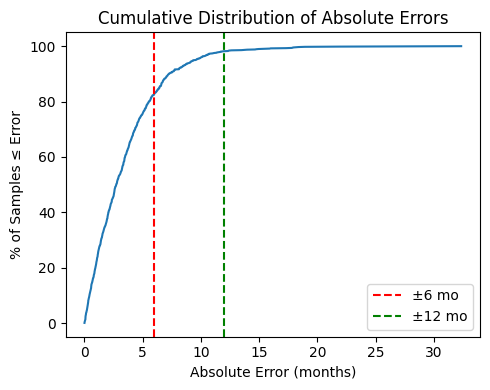

In [39]:
_norm_pred = model.predict(ds_val, verbose=1).flatten()
y_pred      = y_norm_pred * 100.0
y_true      = val_df['boneage_norm'].values * 100.0

# a fresh DataFrame of errors
df_errors = pd.DataFrame({
    'true_age':   y_true,
    'pred_age':   y_pred
})
df_errors['error']     = df_errors['pred_age'] - df_errors['true_age']
df_errors['abs_error'] = df_errors['error'].abs()

# the cumulative distribution of abs_error
errs    = np.sort(df_errors['abs_error'])
cum_perc = np.arange(1, len(errs)+1) / len(errs) * 100

plt.figure(figsize=(5,4))
plt.plot(errs, cum_perc)
plt.axvline(6, color='r', linestyle='--', label='±6 mo')
plt.axvline(12, color='g', linestyle='--', label='±12 mo')
plt.title('Cumulative Distribution of Absolute Errors')
plt.xlabel('Absolute Error (months)')
plt.ylabel('% of Samples ≤ Error')
plt.legend()
plt.tight_layout()
plt.show()


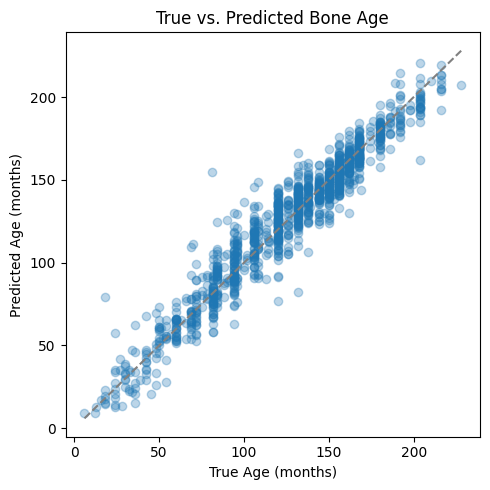

In [40]:
df_results = pd.DataFrame({
    'true_age': y_true_months,
    'pred_age':  y_pred_months
})
#  the scatter plot
plt.figure(figsize=(5,5))
plt.scatter(df_results['true_age'], df_results['pred_age'], alpha=0.3)

mn = min(df_results['true_age'].min(), df_results['pred_age'].min())
mx = max(df_results['true_age'].max(), df_results['pred_age'].max())
plt.plot([mn, mx], [mn, mx], linestyle='--', color='gray')

plt.title('True vs. Predicted Bone Age')
plt.xlabel('True Age (months)')
plt.ylabel('Predicted Age (months)')
plt.tight_layout()
plt.show()



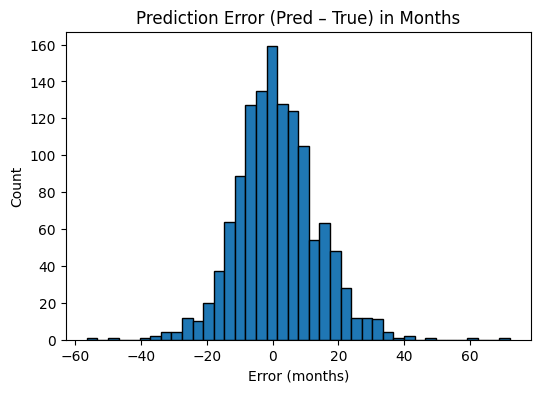

In [41]:
#  Plot histogram of errors
plt.figure(figsize=(6,4))
plt.hist(errors, bins=40, edgecolor='black')
plt.title('Prediction Error (Pred – True) in Months')
plt.xlabel('Error (months)')
plt.ylabel('Count')
plt.show()

In [42]:
# 1) Predict on the validation set again
y_norm_pred = model.predict(ds_val, verbose=1).flatten()
y_pred      = y_norm_pred * 100.0
y_true      = val_df['boneage_norm'].values * 100.0
sex_true    = val_df['sex_norm'].values.astype(int)

# 2) Rebuild the results DataFrame
results_df = pd.DataFrame({
    'true_age':  y_true,
    'pred_age':  y_pred,
    'sex':       sex_true
})
results_df['error']     = results_df['pred_age'] - results_df['true_age']
results_df['abs_error'] = results_df['error'].abs()

# 3) Create age bins if you haven’t already
bin_edges  = [0, 24, 72, np.inf]
bin_labels = ['Infant <2yr','Child 2–6yr','Adolescent >6yr']
results_df['age_bin'] = pd.cut(results_df['true_age'], bins=bin_edges, labels=bin_labels)

# 4) Define the subgroup_metrics function
def subgroup_metrics(df, group_col):
    records = []
    for name, sub in df.groupby(group_col):
        y_t = sub['true_age']
        y_p = sub['pred_age']
        mae  = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        acc6  = (np.abs(y_p - y_t) <= 6).mean()  * 100
        acc12 = (np.abs(y_p - y_t) <= 12).mean() * 100
        records.append({
            group_col: name,
            'count':   len(sub),
            'MAE':     mae,
            'RMSE':    rmse,
            '%≤6mo':   acc6,
            '%≤12mo':  acc12
        })
    return pd.DataFrame.from_records(records)

# 5) Run metrics by age bin and by gender
age_metrics    = subgroup_metrics(results_df, 'age_bin')
gender_metrics = subgroup_metrics(results_df.assign(sex_label=results_df['sex'].map({0:'F',1:'M'})),
                                  'sex_label')

print("Metrics by Age Bin:\n", age_metrics)
print("\nMetrics by Gender:\n", gender_metrics)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
Metrics by Age Bin:
            age_bin  count       MAE      RMSE      %≤6mo     %≤12mo
0      Infant <2yr     84  3.861899  5.614388  82.142857  97.619048
1      Child 2–6yr    960  3.631672  4.895063  81.041667  97.916667
2  Adolescent >6yr    217  2.878249  3.771681  90.322581  99.539171

Metrics by Gender:
   sex_label  count       MAE      RMSE      %≤6mo     %≤12mo
0         F    578  3.604959  4.786514  82.179931  97.923875
1         M    683  3.443220  4.763134  83.162518  98.389458


/tmp/ipykernel_2660535/873613916.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, sub in df.groupby(group_col):


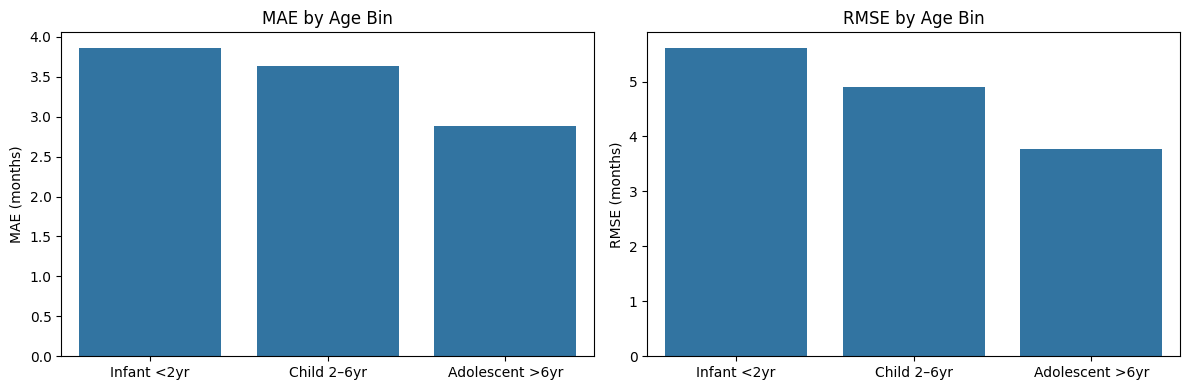

In [43]:
# Map numeric sex → labels
results_df['sex_label'] = results_df['sex'].map({0:'F', 1:'M'})

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=age_metrics, x='age_bin', y='MAE', ax=axes[0])
axes[0].set_title('MAE by Age Bin'); axes[0].set_ylabel('MAE (months)'); axes[0].set_xlabel('')
sns.barplot(data=age_metrics, x='age_bin', y='RMSE', ax=axes[1])
axes[1].set_title('RMSE by Age Bin'); axes[1].set_ylabel('RMSE (months)'); axes[1].set_xlabel('')
plt.tight_layout()
plt.show()



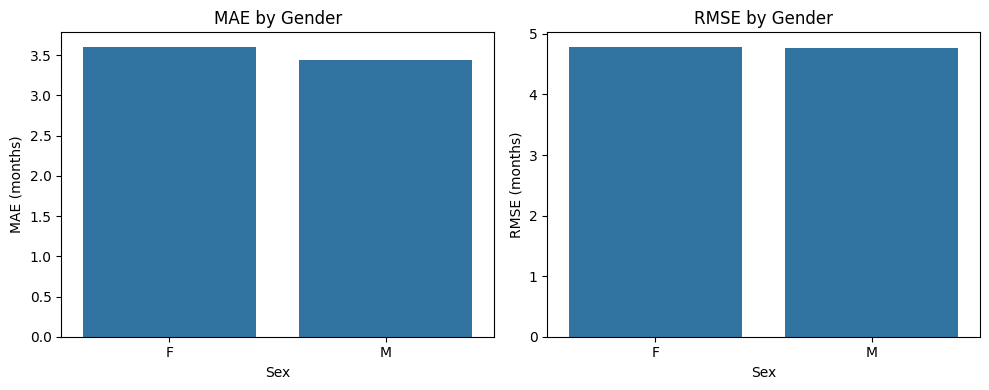

In [44]:
#4) Bar charts of MAE and RMSE by gender
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.barplot(data=gender_metrics, x='sex_label', y='MAE', ax=axes[0])
axes[0].set_title('MAE by Gender'); axes[0].set_ylabel('MAE (months)'); axes[0].set_xlabel('Sex')
sns.barplot(data=gender_metrics, x='sex_label', y='RMSE', ax=axes[1])
axes[1].set_title('RMSE by Gender'); axes[1].set_ylabel('RMSE (months)'); axes[1].set_xlabel('Sex')
plt.tight_layout()
plt.show()




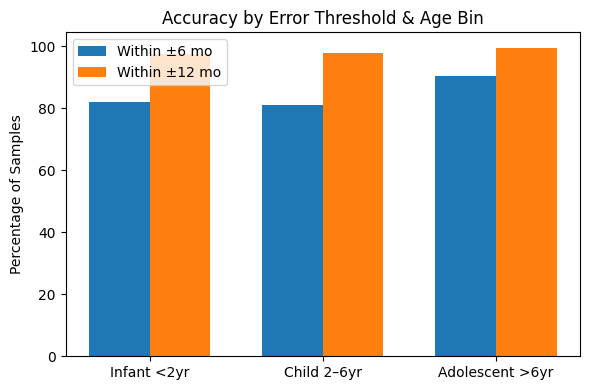

In [45]:
# 2) Bar chart of accuracy within ±6 mo and ±12 mo by age bin
fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(len(age_metrics))
width = 0.35
ax.bar(x - width/2, age_metrics['%≤6mo'], width, label='Within ±6 mo')
ax.bar(x + width/2, age_metrics['%≤12mo'], width, label='Within ±12 mo')
ax.set_xticks(x)
ax.set_xticklabels(age_metrics['age_bin'])
ax.set_ylabel('Percentage of Samples')
ax.set_title('Accuracy by Error Threshold & Age Bin')
ax.legend()
plt.tight_layout()
plt.show()



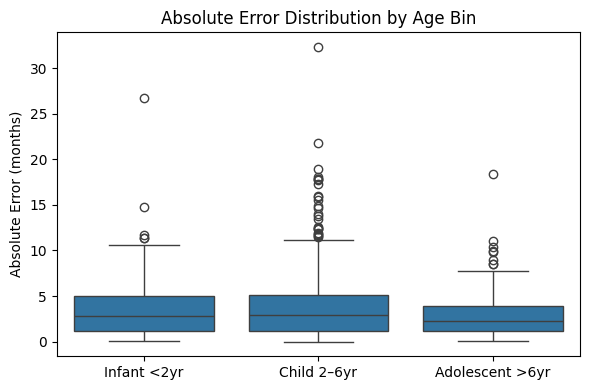

In [46]:
# 3) Boxplot of absolute error by age bin
plt.figure(figsize=(6,4))
sns.boxplot(data=results_df, x='age_bin', y='abs_error', order=age_metrics['age_bin'])
plt.title('Absolute Error Distribution by Age Bin')
plt.ylabel('Absolute Error (months)')
plt.xlabel('')
plt.tight_layout()
plt.show()


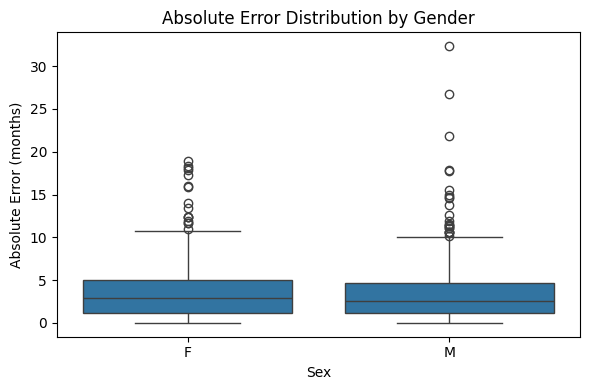

In [47]:
# 5) Boxplot of absolute error by gender
plt.figure(figsize=(6,4))
sns.boxplot(data=results_df, x='sex_label', y='abs_error')
plt.title('Absolute Error Distribution by Gender')
plt.ylabel('Absolute Error (months)')
plt.xlabel('Sex')
plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Scatter of error vs. true_age colored by age_bin')

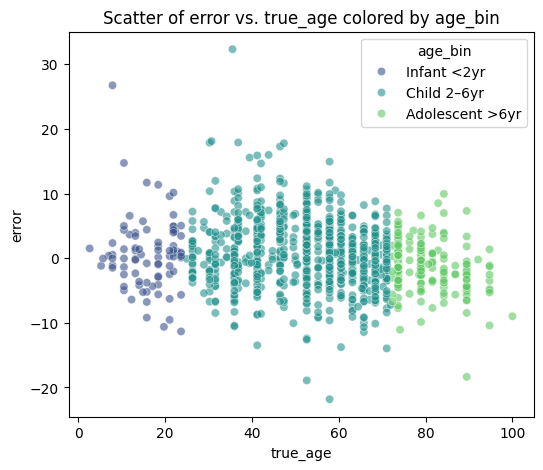

In [48]:
# 6) Scatter of error vs. true_age colored by age_bin
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=results_df,
    x='true_age', y='error',
    hue='age_bin', alpha=0.6,
    palette='viridis'
)
plt.title('Scatter of error vs. true_age colored by age_bin')


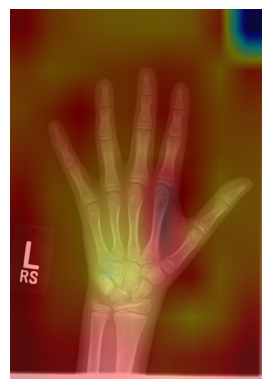

In [49]:
#region agent log
import json, time
debug_path = '/home/spacing/Emir/Boneage UQ/.cursor/debug-395fbc.log'
layer_names = [l.name for l in model.layers]
open(debug_path, 'a', encoding='utf-8').write(json.dumps({'sessionId':'395fbc','runId':'pre-fix','hypothesisId':'H1_H2_H3_H4','location':'RSNA_Pediatric_Bone_Age_Estimation.ipynb:gradcam_cell:entry','message':'Entering GradCAM cell','data':{'layer_count':len(layer_names),'first_layers':layer_names[:8],'has_gap_2':('global_average_pooling2d_2' in layer_names),'has_gap_1':('global_average_pooling2d_1' in layer_names)},'timestamp':int(time.time()*1000)}) + '\n')
#endregion

gap_candidates = [n for n in layer_names if 'global_average_pooling2d' in n]
preferred_order = ['global_average_pooling2d_2', 'global_average_pooling2d_1', 'global_average_pooling2d']
selected_name = next((n for n in preferred_order if n in gap_candidates), gap_candidates[-1] if gap_candidates else None)
if selected_name is None:
    open(debug_path, 'a', encoding='utf-8').write(json.dumps({'sessionId':'395fbc','runId':'post-fix','hypothesisId':'H1_H2','location':'RSNA_Pediatric_Bone_Age_Estimation.ipynb:gradcam_cell:get_layer_error','message':'No GAP layer candidates found','data':{'layer_count':len(layer_names)},'timestamp':int(time.time()*1000)}) + '\n')
    raise ValueError('No global_average_pooling2d layer found for Grad-CAM.')
gap_layer = model.get_layer(selected_name)
open(debug_path, 'a', encoding='utf-8').write(json.dumps({'sessionId':'395fbc','runId':'post-fix','hypothesisId':'H1_H2','location':'RSNA_Pediatric_Bone_Age_Estimation.ipynb:gradcam_cell:get_layer','message':'Resolved GAP layer dynamically','data':{'selected_layer':gap_layer.name,'gap_candidates':gap_candidates},'timestamp':int(time.time()*1000)}) + '\n')
last_conv_tensor = gap_layer.input

# Build the small grad‐model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_tensor, model.output]
)

#  Heatmap generator
def make_gradcam_heatmap(img_np, sex_val, grad_model):
    img_t = tf.convert_to_tensor(img_np, dtype=tf.float32)[None, ...]
    sex_t = tf.convert_to_tensor([[sex_val]], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model([img_t, sex_t])
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv = conv_outputs[0]
    heatmap = tf.reduce_sum(conv * pooled[None,None,:], axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Overlay & display
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    heat = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    jet  = cv2.applyColorMap((heat*255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(jet, alpha, img, 1-alpha, 0)
    plt.imshow(overlay); plt.axis('off'); plt.show()

# Example on a validation case
i = 0
row     = val_df.iloc[i]
img_path = row.filepath
sex_val  = row.sex_norm

# oad at your model's img_size,
orig = load_img(img_path, target_size=img_size)
arr  = img_to_array(orig).astype('float32')
pre  = effnet_preprocess(arr)

# Compute & show
heatmap = make_gradcam_heatmap(pre, sex_val, grad_model)
display_gradcam(img_path, heatmap)